In [31]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Geometry and Database

- Import geometry
- Import TPS dataset
- Merge join to geometry to DPT dataset
- later join to demography and economic database
- find inferences


In [32]:
# import geometry
gdf = gpd.read_file('D:/Files/6. Work/3. Freelance/1. Datakota/2. Politico/politico-master/politico-master/data/DKI.geojson')
gdf.head()

,KODE_KEL_DESA,KODE_KEC,KODE_KAB_KOTA,KODE_PROVINSI,NAMA_KEL_DESA,NAMA_KECAMATAN,NAMA_KAB_KOTA,NAMA_PROVINSI,LUAS_HA,LUAS_SQKM,...,jumlah_pemilih_dpt,pengguna_dpt_lk,pengguna_dpt_pr,pengguna_dptb_lk,pengguna_dptb_pr,pengguna_dpk_lk,pengguna_dpk_pr,jumlah_pengguna_lk,jumlah_pengguna_pr,geometry
0,31.72.05.1003,31.72.05,31.72,31,Ancol,Pademangan,Kota Administrasi Jakarta Utara,DKI Jakarta,826.183438,8.261834,...,6074,2174,2118,903,113,26,45,2151,2512,"POLYGON Z ((42105.862 9322466.466 0.000, 42083..."
1,31.73.04.1007,31.73.04,31.73,31,Angke,Tambora,Kota Administrasi Jakarta Barat,DKI Jakarta,79.870229,0.798702,...,14659,5537,6278,33,23,65,149,5605,6163,"POLYGON Z ((35010.979 9318562.522 0.000, 35010..."
2,31.75.04.1005,31.75.04,31.75,31,Balekambang,Kramatjati,Kota Administrasi Jakarta Timur,DKI Jakarta,169.635973,1.696360,...,11964,5189,4897,206,204,56,63,4662,4929,"POLYGON Z ((41570.433 9305229.563 0.000, 41551..."
3,31.75.03.1003,31.75.03,31.75,31,Bali Mester,Jatinegara,Kota Administrasi Jakarta Timur,DKI Jakarta,67.550190,0.675502,...,4377,2059,2169,47,66,15,31,1563,1700,"POLYGON Z ((41889.209 9311621.356 0.000, 41890..."
4,31.75.10.1006,31.75.10,31.75,31,Bambu Apus,Cipayung,Kota Administrasi Jakarta Timur,DKI Jakarta,354.500695,3.545007,...,3627,1367,1539,9,5,17,27,1393,1569,"POLYGON Z ((47778.435 9301610.681 0.000, 47770..."


In [33]:
# List of columns to calculate percentages for
columns = ['paslon01', 'paslon02', 'paslon03']

# Calculate percentage for each column
for col in columns:
    gdf[f'{col}_%'] = gdf[col] / gdf['total_suara_paslon']
gdf.head()

,KODE_KEL_DESA,KODE_KEC,KODE_KAB_KOTA,KODE_PROVINSI,NAMA_KEL_DESA,NAMA_KECAMATAN,NAMA_KAB_KOTA,NAMA_PROVINSI,LUAS_HA,LUAS_SQKM,...,pengguna_dptb_lk,pengguna_dptb_pr,pengguna_dpk_lk,pengguna_dpk_pr,jumlah_pengguna_lk,jumlah_pengguna_pr,geometry,paslon01_%,paslon02_%,paslon03_%
0,31.72.05.1003,31.72.05,31.72,31,Ancol,Pademangan,Kota Administrasi Jakarta Utara,DKI Jakarta,826.183438,8.261834,...,903,113,26,45,2151,2512,"POLYGON Z ((42105.862 9322466.466 0.000, 42083...",0.420464,0.417434,0.162102
1,31.73.04.1007,31.73.04,31.73,31,Angke,Tambora,Kota Administrasi Jakarta Barat,DKI Jakarta,79.870229,0.798702,...,33,23,65,149,5605,6163,"POLYGON Z ((35010.979 9318562.522 0.000, 35010...",0.272243,0.461961,0.265796
2,31.75.04.1005,31.75.04,31.75,31,Balekambang,Kramatjati,Kota Administrasi Jakarta Timur,DKI Jakarta,169.635973,1.696360,...,206,204,56,63,4662,4929,"POLYGON Z ((41570.433 9305229.563 0.000, 41551...",0.589671,0.315998,0.094331
3,31.75.03.1003,31.75.03,31.75,31,Bali Mester,Jatinegara,Kota Administrasi Jakarta Timur,DKI Jakarta,67.550190,0.675502,...,47,66,15,31,1563,1700,"POLYGON Z ((41889.209 9311621.356 0.000, 41890...",0.332655,0.393832,0.273513
4,31.75.10.1006,31.75.10,31.75,31,Bambu Apus,Cipayung,Kota Administrasi Jakarta Timur,DKI Jakarta,354.500695,3.545007,...,9,5,17,27,1393,1569,"POLYGON Z ((47778.435 9301610.681 0.000, 47770...",0.393960,0.486463,0.119577


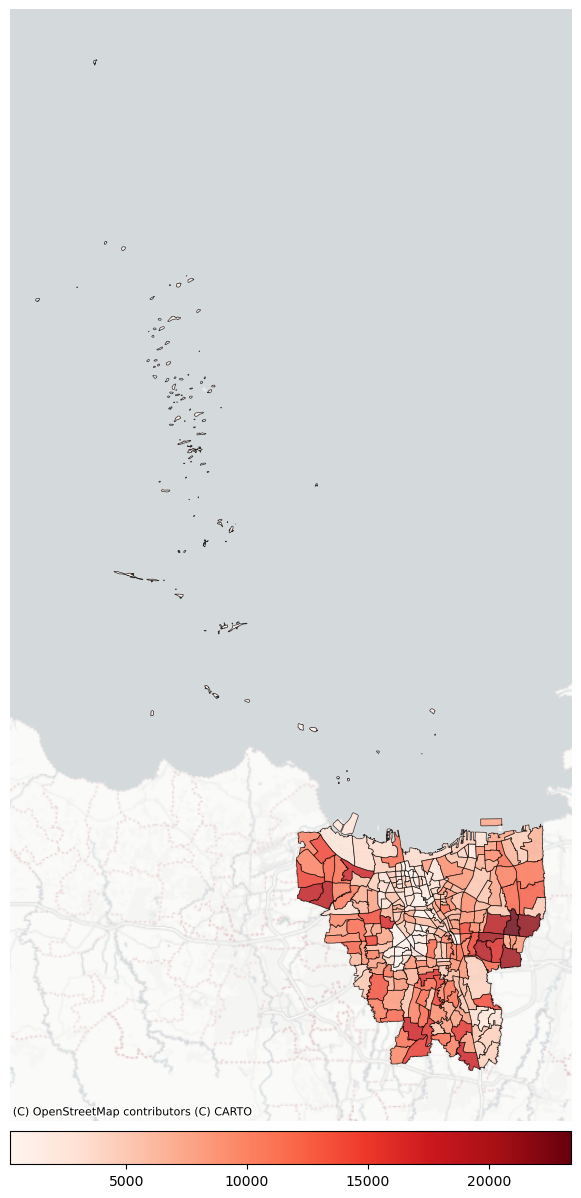

In [34]:
fig, ax = plt.subplots(figsize = (10,15))

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1)

map = gdf.plot(ax=ax,
               column='paslon01',
               edgecolor = 'k',
               cmap = 'Reds',
               linewidth = 0.5,
               legend= True,
               alpha = 0.8,
               cax = cax,
               categorical = False,
               legend_kwds={"orientation": "horizontal"}
               )


map = cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=gdf.crs, zoom=10, )
map = ax.set_axis_off()

map

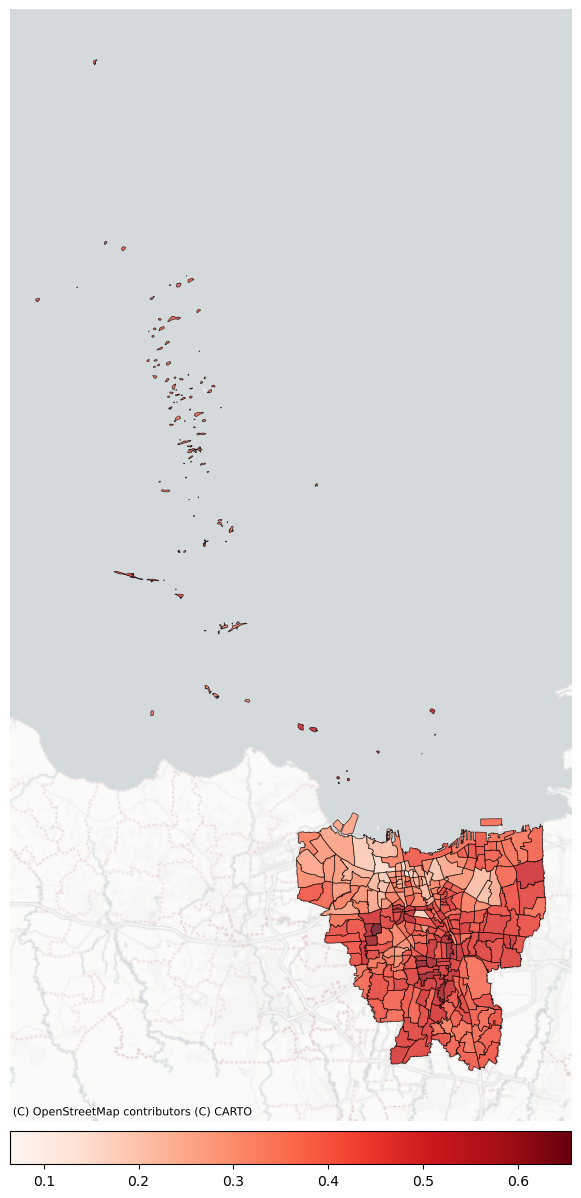

In [35]:
fig, ax = plt.subplots(figsize = (10,15))

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1)

map_prop = gdf.plot(ax=ax,
    column='paslon01_%',
    edgecolor = 'k',
    cmap = 'Reds',
    linewidth = 0.5,
    legend= True,  
    alpha = 0.8,
    cax = cax,
    categorical = False,
    legend_kwds={"orientation": "horizontal"}
    )


map_prop = cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=gdf.crs, zoom=10, )
map_prop = ax.set_axis_off()
map_prop


# Finding most likely winner on each kelurahan

In [36]:
gdf.columns

Index(['KODE_KEL_DESA', 'KODE_KEC', 'KODE_KAB_KOTA', 'KODE_PROVINSI',
       'NAMA_KEL_DESA', 'NAMA_KECAMATAN', 'NAMA_KAB_KOTA', 'NAMA_PROVINSI',
       'LUAS_HA', 'LUAS_SQKM', 'KODE', 'KODE_KEL_DESA_INT', 'TPS_Sliced',
       'paslon01', 'paslon02', 'paslon03', 'total_suara_paslon', 'suara_sah',
       'suara_lebih', 'suara_tidak_sah', 'total_suara', 'pengguna_dpt',
       'pengguna_dptb', 'pengguna_dpk', 'jumlah_pengguna', 'pemilih_dpt_lk',
       'pemilih_dpt_pr', 'jumlah_pemilih_dpt', 'pengguna_dpt_lk',
       'pengguna_dpt_pr', 'pengguna_dptb_lk', 'pengguna_dptb_pr',
       'pengguna_dpk_lk', 'pengguna_dpk_pr', 'jumlah_pengguna_lk',
       'jumlah_pengguna_pr', 'geometry', 'paslon01_%', 'paslon02_%',
       'paslon03_%'],
      dtype='object')

In [37]:
# Select relevant columns for gdf_most and create a copy
df_most = gdf[['NAMA_KEL_DESA', 'NAMA_KECAMATAN', 'NAMA_KAB_KOTA', 'paslon01_%', 'paslon02_%', 'paslon03_%']].copy()

# Define the list of percentage columns to rank
numeric_columns = ['paslon01_%', 'paslon02_%', 'paslon03_%']

# Define a function to get the sorted column names based on row values
def get_sorted_columns(row):
    numeric_row = row[numeric_columns]
    return numeric_row.sort_values(ascending=False).index.tolist()

# Apply the function to each row and create a new column with sorted percentages
df_most['sorted'] = df_most.apply(get_sorted_columns, axis=1)

# Extract the ranked columns into separate new columns
for i in range(3):
    df_most[f'rank_{i+1}'] = df_most['sorted'].apply(lambda x: x[i] if len(x) > i else np.nan)

# Drop the temporary 'sorted' column
df_most = df_most.drop(columns=['sorted'])

# Renaming values in rank columns
rename_dict = {
    'paslon01_%': 'paslon01',
    'paslon02_%': 'paslon02',
    'paslon03_%': 'paslon03'
}

df_most['rank1'] = df_most['rank_1'].replace(rename_dict)
df_most['rank2'] = df_most['rank_2'].replace(rename_dict)
df_most['rank3'] = df_most['rank_3'].replace(rename_dict)
df_most


,NAMA_KEL_DESA,NAMA_KECAMATAN,NAMA_KAB_KOTA,paslon01_%,paslon02_%,paslon03_%,rank_1,rank_2,rank_3,rank1,rank2,rank3
0,Ancol,Pademangan,Kota Administrasi Jakarta Utara,0.420464,0.417434,0.162102,paslon01_%,paslon02_%,paslon03_%,paslon01,paslon02,paslon03
1,Angke,Tambora,Kota Administrasi Jakarta Barat,0.272243,0.461961,0.265796,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03
2,Balekambang,Kramatjati,Kota Administrasi Jakarta Timur,0.589671,0.315998,0.094331,paslon01_%,paslon02_%,paslon03_%,paslon01,paslon02,paslon03
3,Bali Mester,Jatinegara,Kota Administrasi Jakarta Timur,0.332655,0.393832,0.273513,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03
4,Bambu Apus,Cipayung,Kota Administrasi Jakarta Timur,0.393960,0.486463,0.119577,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03
...,...,...,...,...,...,...,...,...,...,...,...,...
262,Pulau Pari,Kepulauan Seribu Selatan,Administrasi Kepulauan Seribu,0.341604,0.552060,0.106336,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03
263,Pulau Harapan,Kepulauan Seribu Utara,Administrasi Kepulauan Seribu,0.390273,0.490510,0.119217,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03
264,Pulau Kelapa,Kepulauan Seribu Utara,Administrasi Kepulauan Seribu,0.351457,0.510299,0.138245,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03
265,Pulau Panggang,Kepulauan Seribu Utara,Administrasi Kepulauan Seribu,0.354005,0.487572,0.158423,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03


In [38]:
# Exporting into csv
output_csv_path = 'D:/Files/6. Work/3. Freelance/1. Datakota/2. Politico/politico-master/politico-master/data/DKI_rank.csv'
df_most.to_csv(output_csv_path, index=False)
print(f"DataFrame exported to {output_csv_path}")

DataFrame exported to D:/Files/6. Work/3. Freelance/1. Datakota/2. Politico/politico-master/politico-master/data/DKI_rank.csv


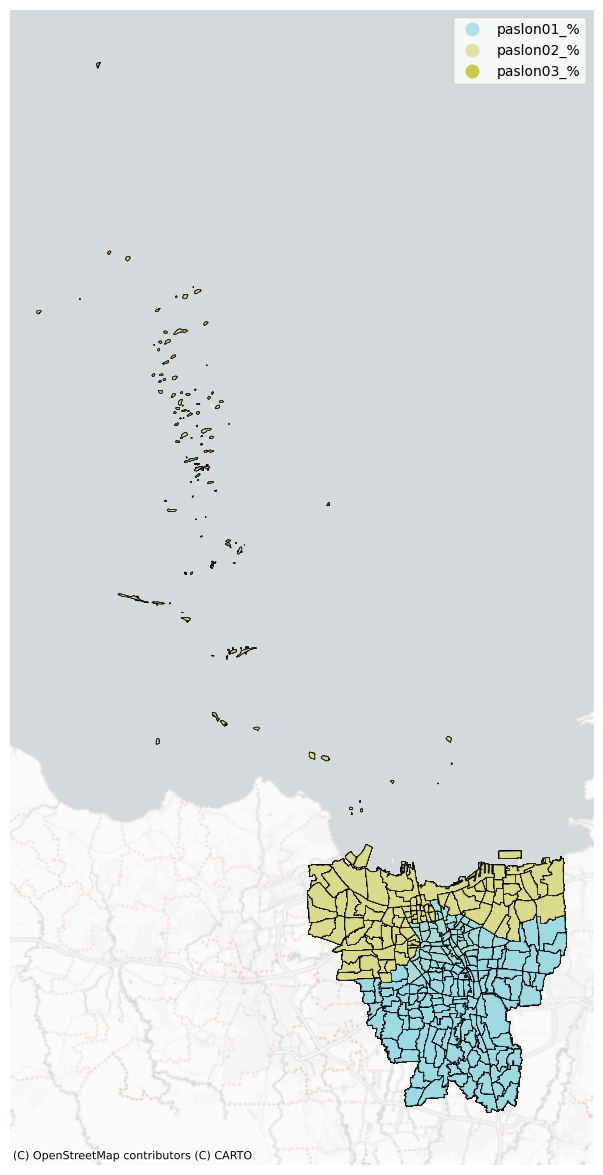

In [39]:
from matplotlib.colors import ListedColormap

df_most2 = df_most.copy().drop(columns = ['paslon01_%', 'paslon02_%', 'paslon03_%'])
gdf_a = pd.merge(gdf, df_most2, on = 'NAMA_KAB_KOTA', how= 'left')
    
# Define a custom colormap
candidates = df_most2.columns[:4].tolist()
# candidates = gdf_a['rank_1'].unique().tolist() # + gdf_a['rank_2'].unique().tolist() + gdf_a['rank_3'].unique().tolist()
# candidates = list(set(candidates))  # Ensure unique candidates
candidates.sort(reverse=False)

# Define colors (you can specify your own colors here)
colors = plt.cm.tab20_r.colors[:len(candidates)]  # Use the Set3 colormap for as many colors as candidates
cmap = ListedColormap(colors)

# Create a dictionary for candidate to color mapping
# candidate_color_map = {candidate: colors[i] for i, candidate in enumerate(candidates)}

# Function to plot the map for a given rank
def plot_rank_map(rank_column, ax):
    gdf_a.plot(ax=ax,
               column=rank_column,
               edgecolor='k',
               linewidth=0.5,
               legend=True,
               alpha=0.8,
               cmap=cmap,
               categorical=True)
    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=gdf_a.crs.to_string(), zoom=10)
    ax.set_axis_off()

# Plotting each rank map
# fig, axs = plt.subplots(3, 1, figsize=(10, 15))

fig, ax = plt.subplots(figsize = (10,15))
plot_rank_map('rank_1', ax)

# plot_rank_map('rank_2', axs[1])
# # axs[1].set_title('Rank 2')

# plot_rank_map('rank_3', axs[2])
# # axs[2].set_title('Rank 3')

# Kelurahan recapitulation

In [40]:
gdf_a.columns

Index(['KODE_KEL_DESA', 'KODE_KEC', 'KODE_KAB_KOTA', 'KODE_PROVINSI',
       'NAMA_KEL_DESA_x', 'NAMA_KECAMATAN_x', 'NAMA_KAB_KOTA', 'NAMA_PROVINSI',
       'LUAS_HA', 'LUAS_SQKM', 'KODE', 'KODE_KEL_DESA_INT', 'TPS_Sliced',
       'paslon01', 'paslon02', 'paslon03', 'total_suara_paslon', 'suara_sah',
       'suara_lebih', 'suara_tidak_sah', 'total_suara', 'pengguna_dpt',
       'pengguna_dptb', 'pengguna_dpk', 'jumlah_pengguna', 'pemilih_dpt_lk',
       'pemilih_dpt_pr', 'jumlah_pemilih_dpt', 'pengguna_dpt_lk',
       'pengguna_dpt_pr', 'pengguna_dptb_lk', 'pengguna_dptb_pr',
       'pengguna_dpk_lk', 'pengguna_dpk_pr', 'jumlah_pengguna_lk',
       'jumlah_pengguna_pr', 'geometry', 'paslon01_%', 'paslon02_%',
       'paslon03_%', 'NAMA_KEL_DESA_y', 'NAMA_KECAMATAN_y', 'rank_1', 'rank_2',
       'rank_3', 'rank1', 'rank2', 'rank3'],
      dtype='object')

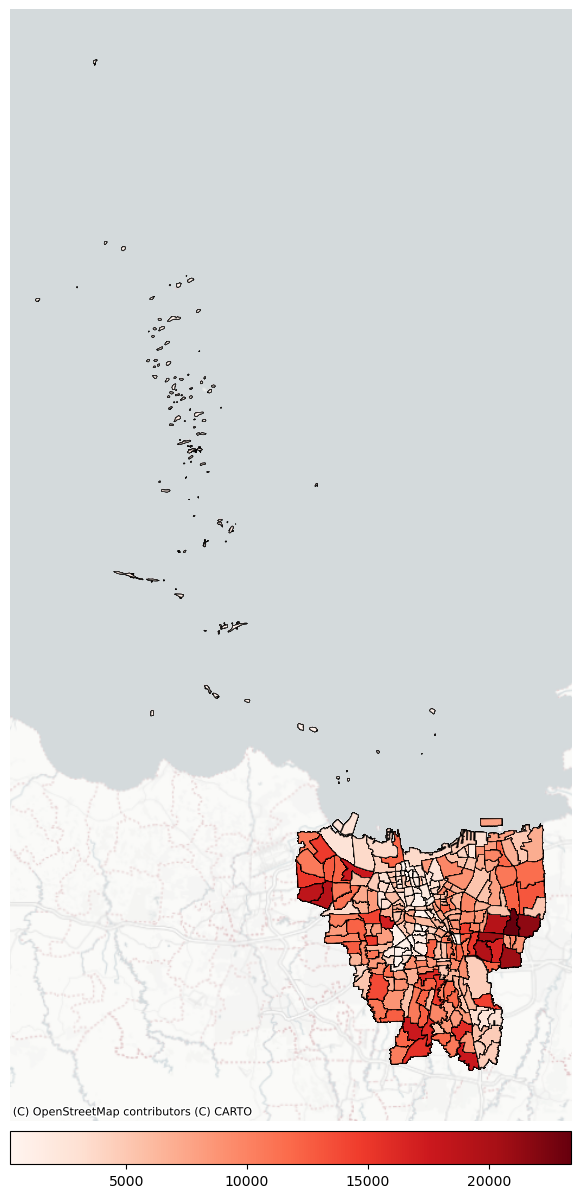

In [41]:
#gdf_a = pd.merge(gdf_dpt, df_a, on = 'NAMA_KAB_KOTA', how= 'left')
    

fig, ax = plt.subplots(figsize = (10,15))

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1)

map = gdf_a.plot(ax=ax,
    column='paslon01',
    edgecolor = 'k',
    cmap = 'Reds',
    linewidth = 0.5,
    legend= True,  
    alpha = 0.8,
    cax = cax,
    categorical = False,
    legend_kwds={"orientation": "horizontal"}
    )


map = cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=gdf_a.crs, zoom=10, )
map = ax.set_axis_off()

map

In [42]:
Q1 = gdf_a['paslon01'].quantile(0.25)
Q2 = gdf_a['paslon01'].median()
Q3 = gdf_a['paslon01'].quantile(0.75)

Q1, Q2, Q3

(4014.0, 6963.0, 10435.0)

In [43]:
gdf_a['Kategori_Kelurahan'] = ''
for i in range(0,len(gdf_a)):
    if gdf_a['paslon01'][i] <= Q1:
        gdf_a['Kategori_Kelurahan'][i] = 'C_Weak'
    elif gdf_a['paslon01'][i] <= Q3:
        gdf_a['Kategori_Kelurahan'][i] = 'B_Moderate'
    else:
        gdf_a['Kategori_Kelurahan'][i] = 'A_Strong'


gdf_a.head()

C:\Users\irsra\AppData\Local\Temp\ipykernel_28064\472081064.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_a['Kategori_Kelurahan'][i] = 'C_Weak'
C:\Users\irsra\AppData\Local\Temp\ipykernel_28064\472081064.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_a['Kategori_Kelurahan'][i] = 'B_Moderate'
C:\Users\irsra\AppData\Local\Temp\ipykernel_28064\472081064.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_a['Kategori

,KODE_KEL_DESA,KODE_KEC,KODE_KAB_KOTA,KODE_PROVINSI,NAMA_KEL_DESA_x,NAMA_KECAMATAN_x,NAMA_KAB_KOTA,NAMA_PROVINSI,LUAS_HA,LUAS_SQKM,...,paslon03_%,NAMA_KEL_DESA_y,NAMA_KECAMATAN_y,rank_1,rank_2,rank_3,rank1,rank2,rank3,Kategori_Kelurahan
0,31.72.05.1003,31.72.05,31.72,31,Ancol,Pademangan,Kota Administrasi Jakarta Utara,DKI Jakarta,826.183438,8.261834,...,0.162102,Ancol,Pademangan,paslon01_%,paslon02_%,paslon03_%,paslon01,paslon02,paslon03,C_Weak
1,31.72.05.1003,31.72.05,31.72,31,Ancol,Pademangan,Kota Administrasi Jakarta Utara,DKI Jakarta,826.183438,8.261834,...,0.162102,Cilincing,Cilincing,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03,C_Weak
2,31.72.05.1003,31.72.05,31.72,31,Ancol,Pademangan,Kota Administrasi Jakarta Utara,DKI Jakarta,826.183438,8.261834,...,0.162102,Kalibaru,Cilincing,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03,C_Weak
3,31.72.05.1003,31.72.05,31.72,31,Ancol,Pademangan,Kota Administrasi Jakarta Utara,DKI Jakarta,826.183438,8.261834,...,0.162102,Kamal Muara,Penjaringan,paslon02_%,paslon01_%,paslon03_%,paslon02,paslon01,paslon03,C_Weak
4,31.72.05.1003,31.72.05,31.72,31,Ancol,Pademangan,Kota Administrasi Jakarta Utara,DKI Jakarta,826.183438,8.261834,...,0.162102,Kapuk Muara,Penjaringan,paslon02_%,paslon03_%,paslon01_%,paslon02,paslon03,paslon01,C_Weak


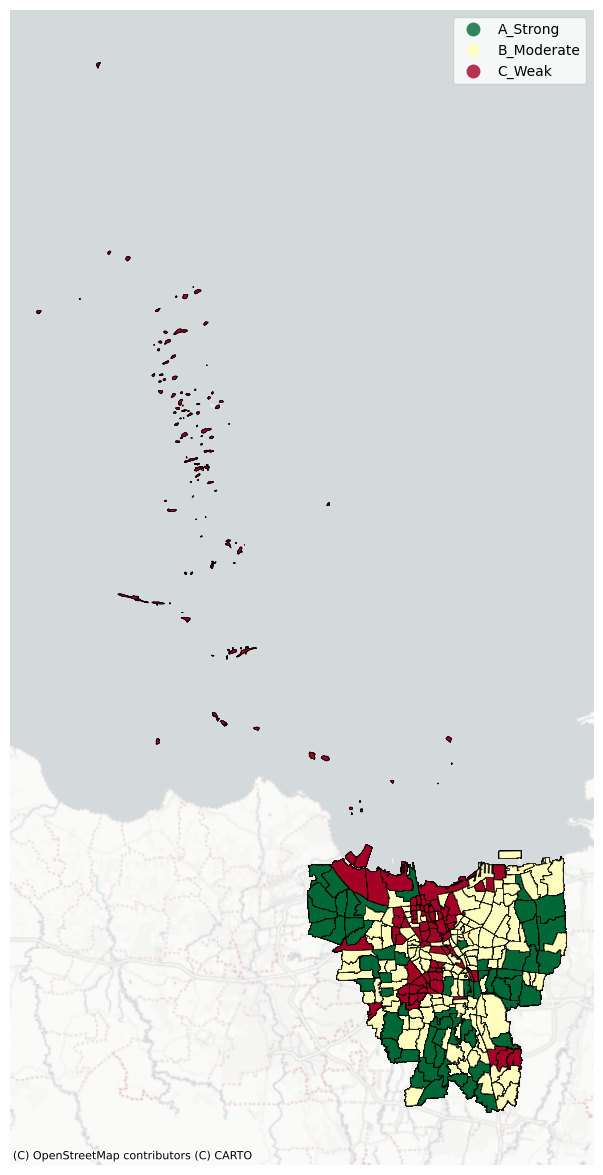

In [44]:
#gdf_a = pd.merge(gdf_dpt, df_a, on = 'NAMA_KAB_KOTA', how= 'left')
    

fig, ax = plt.subplots(figsize = (10,15))

# divider = make_axes_locatable(ax)
# cax = divider.append_axes("bottom", size="3%", pad=0.1)

map = gdf_a.plot(ax=ax,
    column='Kategori_Kelurahan',
    edgecolor = 'k',
    cmap = 'RdYlGn_r',
    linewidth = 0.5,
    legend= True,  
    alpha = 0.8,
    #cax = cax,
    categorical = True,
    #legend_kwds={"orientation": "horizontal"}
    )


map = cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=gdf_a.crs, zoom=10, )
map = ax.set_axis_off()

map

In [45]:
# gdf_a['Undecided_total'] = gdf_a['TIDAK TAHU'] * gdf_a['DPT_total']
# gdf_a['Non_Big_3'] = gdf_a['DPT_total'] - gdf_a['Andi_Total'] - gdf_a['Tina_Total'] - gdf_a['Lukman_Total']
# 
# fig, ax = plt.subplots(figsize = (10,15))
# 
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("bottom", size="3%", pad=0.1)
# 
# map = gdf_a.plot(ax=ax,
#     column='Non_Big_3',
#     edgecolor = 'k',
#     cmap = 'Greys',
#     linewidth = 0.5,
#     legend= True,  
#     alpha = 0.8,
#     cax = cax,
#     categorical = False,
#     legend_kwds={"orientation": "horizontal"}
#     )
# 
# 
# map = cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=gdf_dpt.crs, zoom=10, )
# map = ax.set_axis_off()
# 
# map

# Ekonomi

In [46]:
# # import data
# df = pd.read_csv('data/INDODAPOERData.csv')
# df

,Country Name,Country Code,Indicator Name,Indicator Code,1976,1977,1978,1979,1980,1981,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,"Nanggroe Aceh Darussalam, Prop.",ID.AC,Agriculture function expenditure (in IDR),FC.XPD.AGR.CR,NaN,NaN,NaN,NaN,NaN,NaN,...,6.327770e+11,7.419380e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Nanggroe Aceh Darussalam, Prop.",ID.AC,Average National Exam Score: Junior Secondary ...,SE.NEXM.SCR.JRSEC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Nanggroe Aceh Darussalam, Prop.",ID.AC,Average National Exam Score: Primary Level (ou...,SE.NEXM.SCR.PRM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Nanggroe Aceh Darussalam, Prop.",ID.AC,Average National Exam Score: Senior Secondary ...,SE.NEXM.SCR.SRSEC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Nanggroe Aceh Darussalam, Prop.",ID.AC,Birth attended by Skilled Health worker (in % ...,SH.STA.BRTC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.964925e+01,9.170405e+01,91.97438,9.361602e+01,9.539587e+01,9.627755e+01,9.787111e+01,9.774794e+01,9.825797e+01,9.823791e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150147,"Tapanuli Utara, Kab.",ID.SU.TU,Tourism and culture function expenditure (in IDR),FC.XPD.TOUR.CR,NaN,NaN,NaN,NaN,NaN,NaN,...,4.145007e+09,3.552772e+09,NaN,3.916585e+09,5.244011e+09,6.215014e+09,4.416545e+09,1.016965e+10,1.149086e+10,8.319606e+09
150148,"Tapanuli Utara, Kab.",ID.SU.TU,Villages with road: Asphalt (in % of total vil...,ROD.VILG.ASPH.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.000000e+01,NaN,NaN,7.261905e+01,NaN,NaN,NaN,8.730159e+01,NaN,NaN
150149,"Tapanuli Utara, Kab.",ID.SU.TU,Villages with road: Dirt (in % of total villages),ROD.VILG.DIRT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.250000e+00,NaN,NaN,3.968254e+00,NaN,NaN,NaN,3.174603e+00,NaN,NaN
150150,"Tapanuli Utara, Kab.",ID.SU.TU,Villages with road: Gravel (in % of total vill...,ROD.VILG.GRAVL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.333333e+01,NaN,NaN,2.142857e+01,NaN,NaN,NaN,9.523810e+00,NaN,NaN


In [53]:
# list(df['Indicator Name'].unique())

In [54]:
# list(df['Country Name'].unique())

# DKI Jakarta

In [51]:
# df_ST = df[df['Country Name']== 'DKI Jakarta, Prop.']
# df_ST

In [52]:
# df_ST[df_ST['Indicator Name'] == 'Number of people unemployed'].T